# SylloGym — Evaluation (Apple Silicon / MLX)

Evaluates a baseline model or a fine-tuned GRPO checkpoint on the SylloGym Judge environment (multi-turn).

**Available analyses:**
- Accuracy by task and by number of turns
- Twist resistance (plot-twist turns vs neutral turns)
- Sycophancy: does the model blindly follow the last revealed fact even when the correct answer hasn't changed?
- Qualitative analysis of `<think>` reasoning before/after training
- Baseline vs checkpoint comparison on a fixed dataset (seed=42)

**Requirements:** ~5 GB unified RAM (Qwen3-4B in 4-bit via MLX).

## 1. Install

In [1]:
import subprocess, sys, os

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

pip('mlx-lm>=0.20.0', 'openenv-core>=0.2.1', 'matplotlib', 'tqdm', 'numpy')

REPO_ROOT = os.path.abspath('..')
ENVS_PATH = os.path.join(REPO_ROOT, 'envs')
if ENVS_PATH not in sys.path:
    sys.path.insert(0, ENVS_PATH)

import importlib; importlib.invalidate_caches()

from syllogym_env import JudgeEnv

_env = JudgeEnv(seed=0)
_obs = _env.reset()
print(f'Env OK : task={_obs.task_name}  turns={_obs.total_layers}')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Env OK : task=sof_3  turns=3


## 2. Configuration

In [ ]:
# ── Models ─────────────────────────────────────────────────────────────────────
BASE_MODEL       = 'Qwen/Qwen3-1.7B'   # base model (HF hub or local path)
CHECKPOINT_MODEL = 'farffadet/syllogym-judge-qwen3-1b-grpo-v12-checkpoints'
CHECKPOINT_STEP  = 180                  # checkpoint-{step} subfolder to evaluate

MAX_NEW_TOKENS = 3072  # must match MAX_COMPLETION_LEN used during training

# ── Eval ───────────────────────────────────────────────────────────────────────
EVAL_EPISODES = 20  # per task (20 = precise for the paper, 5 = quick)
EVAL_SEED     = 42  # fixed seed → reproducible, valid baseline/checkpoint comparison

# Canonical list of tasks to evaluate
EVAL_TASKS = [
    'diversity_4', 'diversity_5',
    'ucc_4',
    'miranda_4', 'miranda_5',
    'consideration_2', 'consideration_3', 'consideration_4',
    'mens_rea_2', 'mens_rea_3',
    'terry_2', 'terry_3', 'terry_4',
    'sara_s7703_3',
    'sof_4',
    'hearsay_2', 'hearsay_3', 'hearsay_4',
    'adverse_possession_4', 'adverse_possession_5',
]

_ckpt_path = f'{CHECKPOINT_MODEL}/checkpoint-{CHECKPOINT_STEP}' if CHECKPOINT_MODEL else None
print(f'Base      : {BASE_MODEL}')
print(f'Checkpoint: {_ckpt_path or "(not set — baseline only)"}')
print(f'Episodes  : {EVAL_EPISODES} x {len(EVAL_TASKS)} tasks = {EVAL_EPISODES * len(EVAL_TASKS)} total')
print(f'Seed      : {EVAL_SEED}')

## 3. Load Models (MLX)

In [ ]:
from mlx_lm import load, generate as mlx_generate
from huggingface_hub import snapshot_download
import os, subprocess, sys, json

print(f'Loading baseline: {BASE_MODEL} ...')
base_model, base_tokenizer = load(BASE_MODEL)
print('  OK')

ckpt_model, ckpt_tokenizer = None, None
if CHECKPOINT_MODEL:
    _hf_subfolder = f'checkpoint-{CHECKPOINT_STEP}'
    _mlx_path = os.path.expanduser(f'~/.cache/syllogym_checkpoints/step{CHECKPOINT_STEP}-mlx')

    if not os.path.exists(os.path.join(_mlx_path, 'config.json')):
        print(f'Converting LoRA → MLX...')

        # 1. Download the LoRA adapter from HF
        _adapter_cache = os.path.expanduser(f'~/.cache/syllogym_checkpoints/step{CHECKPOINT_STEP}')
        snapshot_download(
            repo_id=CHECKPOINT_MODEL,
            allow_patterns=f'{_hf_subfolder}/*',
            local_dir=_adapter_cache,
        )
        _adapter_path = os.path.join(_adapter_cache, _hf_subfolder)

        # 2. Merge PEFT → HF format with transformers
        import torch
        from transformers import AutoModelForCausalLM, AutoTokenizer
        from peft import PeftModel

        _merged_hf = os.path.expanduser(f'~/.cache/syllogym_checkpoints/step{CHECKPOINT_STEP}-hf')
        if not os.path.exists(os.path.join(_merged_hf, 'config.json')):
            print(f'  Merging PEFT (transformers)...')
            _base = AutoModelForCausalLM.from_pretrained(BASE_MODEL, torch_dtype=torch.float16)
            _tok  = AutoTokenizer.from_pretrained(BASE_MODEL)
            _peft = PeftModel.from_pretrained(_base, _adapter_path)
            _peft.merge_and_unload().save_pretrained(_merged_hf)
            _tok.save_pretrained(_merged_hf)
            del _base, _peft
            print(f'  Saved HF → {_merged_hf}')

        # 3. Patch config.json: mlx_lm rejects rope_theta=null
        _cfg_path = os.path.join(_merged_hf, 'config.json')
        with open(_cfg_path) as f:
            _cfg = json.load(f)
        _patched = False
        if not _cfg.get('rope_theta'):
            _cfg['rope_theta'] = 1000000.0  # Qwen3 default value
            _patched = True
        if not _cfg.get('rope_scaling'):
            _cfg['rope_scaling'] = None  # leave absent rather than null
            del _cfg['rope_scaling']
            _patched = True
        if _patched:
            with open(_cfg_path, 'w') as f:
                json.dump(_cfg, f, indent=2)
            print(f'  Patched config.json (rope_theta=1000000.0)')

        # 4. Convert HF → MLX with mlx_lm.convert
        print(f'  Converting HF → MLX...')
        subprocess.run([
            sys.executable, '-m', 'mlx_lm', 'convert',
            '--hf-path', _merged_hf,
            '--mlx-path', _mlx_path,
            '--dtype', 'float16',
        ], check=True)
        print(f'  Saved MLX → {_mlx_path}')
    else:
        print(f'MLX model already cached: {_mlx_path}')

    print(f'Loading checkpoint (MLX): {_mlx_path} ...')
    ckpt_model, ckpt_tokenizer = load(_mlx_path)
    print('  OK')

print('Models ready.')

## 4. Helpers

In [ ]:
import re, json, logging
import numpy as np
from syllogym_env import JudgeEnv, JudgeObs

# ── Logger ────────────────────────────────────────────────────────────────────
eval_logger = logging.getLogger('syllogym_eval')
eval_logger.setLevel(logging.DEBUG)
eval_logger.handlers.clear()
_fh = logging.FileHandler('eval.log', mode='w', encoding='utf-8')
_fh.setFormatter(logging.Formatter('%(message)s'))
eval_logger.addHandler(_fh)
eval_logger.propagate = False
def log(msg=''): eval_logger.info(msg)

# ── System prompt (identical to training) ─────────────────────────────────────
SYSTEM_PROMPT = """You are an expert judge. You will receive facts about a legal case one step at a time.
At each step, answer the question with exactly one of the valid answers listed (e.g. Yes or No).
Reason carefully — new information may require you to revise your previous ruling.

Think briefly (2-3 sentences max) before answering. Be concise.

Format your answer as:
<answer>Yes</answer>  or  <answer>No</answer>

Always end with the <answer> tag."""


# ── Prompt format (identical to training) ─────────────────────────────────────
def format_turn_prompt(obs: JudgeObs) -> str:
    if obs.layer_index == 0:
        return (
            f"[APPLICABLE LAW]\n{obs.rule}\n\n"
            f"[CASE FACTS]\n{obs.facts}\n\n"
            f"[QUESTION — Turn {obs.layer_index + 1}/{obs.total_layers}]\n"
            f"{obs.question}\n"
            f"Valid answers: {' | '.join(obs.valid_answers)}"
        )
    parts = []
    if obs.new_info:
        tag = 'CORRECTION' if obs.is_twist else 'NEW INFORMATION'
        parts.append(f'[{tag}]\n{obs.new_info}')
    parts.append(
        f"[QUESTION — Turn {obs.layer_index + 1}/{obs.total_layers}]\n"
        f"{obs.question}\n"
        f"Valid answers: {' | '.join(obs.valid_answers)}"
    )
    return '\n\n'.join(parts)


def parse_answer(text: str, valid_answers: list) -> str:
    m = re.search(r'<answer>\s*(.+?)\s*</answer>', text, re.IGNORECASE)
    if m:
        return m.group(1).strip()
    for v in valid_answers:
        if re.search(r'\b' + re.escape(v) + r'\b', text, re.IGNORECASE):
            return v
    return valid_answers[0]


def generate_response(model, tokenizer, messages: list) -> str:
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    return mlx_generate(
        model, tokenizer,
        prompt=prompt,
        max_tokens=MAX_NEW_TOKENS,
        verbose=False,
    )


def run_episode(model, tokenizer, task_name=None, seed=None) -> dict:
    """Run a complete multi-turn episode. Returns a rich result dict."""
    env = JudgeEnv(seed=seed)
    obs = env.reset(task_name=task_name)
    if obs.done:
        return {'task_name': task_name, 'reward': 0.0, 'turns': [], 'n_turns': 0}

    log(); log('=' * 72)
    log(f'EPISODE  task={obs.task_name}  seed={seed}')
    log('=' * 72)

    messages = [{'role': 'system', 'content': SYSTEM_PROMPT}]
    turn_log = []

    while not obs.done:
        user_msg = format_turn_prompt(obs)
        messages.append({'role': 'user', 'content': user_msg})
        log(f'--- Turn {obs.layer_index + 1}/{obs.total_layers} ---')
        log(user_msg)

        response = generate_response(model, tokenizer, messages)
        log(f'[MODEL] {response}')

        # Extract thinking block
        think_m = re.search(r'<think>(.*?)</think>', response, re.DOTALL)
        thinking = think_m.group(1).strip() if think_m else ''

        answer = parse_answer(response, obs.valid_answers)
        correct_answer = obs.valid_answers[0]  # overwritten after step

        turn_log.append({
            'turn_idx': obs.layer_index,
            'is_twist': obs.is_twist,
            'answer': answer,
            'thinking': thinking,
            'new_info': obs.new_info,
        })

        messages.append({'role': 'assistant', 'content': response})
        obs = env.step(answer)

        # Annotate turn_log with correct answer when episode ends
        if obs.done and obs.correct_answer:
            turn_log[-1]['correct_answer'] = obs.correct_answer
            turn_log[-1]['correct'] = (answer.strip().lower() == obs.correct_answer.strip().lower())
        else:
            turn_log[-1]['correct'] = True  # intermediate answer is correct if we continue

        log(f'  reward={obs.reward}  done={obs.done}')

    return {
        'task_name': task_name or env.episode.task_name,
        'n_turns': env.total_turns,
        'reward': env.reward,
        'correct': env.reward > 0,
        'turns': turn_log,
    }


print('Helpers ready. Logs → eval.log')

## 5. Evaluation

Runs baseline + checkpoint (if defined) on the same fixed dataset (seed=42).

In [ ]:
def save_eval(ev: dict, path: str):
    with open(path, 'w') as f:
        json.dump(ev, f, indent=2)
    print(f'Saved → {path}')


from tqdm import tqdm
import os

PARTIAL_DIR = '.'  # directory for intermediate saves

def _partial_path(label: str) -> str:
    return os.path.join(PARTIAL_DIR, f'eval_{label}_partial.json')

def _load_partial(label: str) -> dict | None:
    """Load a partial save if it exists."""
    path = _partial_path(label)
    if not os.path.exists(path):
        return None
    try:
        with open(path) as f:
            data = json.load(f)
        done = list(data.get('task_scores', {}).keys())
        print(f'  [resume] {label}: {len(done)} tasks already done → resuming')
        return data
    except Exception as e:
        print(f'  [resume] Partial file corrupted, starting from scratch ({e})')
        return None

def _save_partial(label: str, task_scores: dict, all_results: list):
    """Save partial progress after each task."""
    path = _partial_path(label)
    data = {
        'label': label,
        'task_scores': task_scores,
        'results': all_results,   # episodes completed so far
    }
    with open(path, 'w') as f:
        json.dump(data, f)

def run_eval(model, tokenizer, label='baseline', baseline_ev=None) -> dict:
    """Evaluate a model on all tasks. Returns a dict of results.

    - Saves intermediate progress after each task → eval_{label}_partial.json
    - Automatically resumes if the cell crashed (existing partial file)
    - If baseline_ev is provided, shows Δ acc and Δ reward per task in real time.
    """
    # ── Resume ───────────────────────────────────────────────────────────────
    partial = _load_partial(label)
    if partial:
        task_scores = partial.get('task_scores', {})
        all_results = partial.get('results', [])
    else:
        task_scores = {}
        all_results = []

    tasks_todo = [t for t in EVAL_TASKS if t not in task_scores]

    print(f'=== SylloGym Judge — {label} ===')
    print(f'    {EVAL_EPISODES} episodes x {len(EVAL_TASKS)} tasks | seed={EVAL_SEED}')
    if task_scores:
        print(f'    {len(task_scores)} tasks already done, {len(tasks_todo)} remaining')
    if baseline_ev:
        print(f'    (comparing vs {baseline_ev["label"]})')
    print()

    # Re-display already completed tasks (for context)
    for task, scores in task_scores.items():
        acc = scores['accuracy']
        rew = scores['mean_reward']
        if baseline_ev and task in baseline_ev.get('task_scores', {}):
            b = baseline_ev['task_scores'][task]
            d_acc = acc - b['accuracy']
            d_rew = rew - b['mean_reward']
            color = '\033[32m' if d_acc > 0.05 else ('\033[31m' if d_acc < -0.05 else '\033[90m')
            extra = f'  {color}Δacc={d_acc:+.0%}  Δrew={d_rew:+.3f}\033[0m'
        else:
            extra = ''
        print(f'  {task:<28s}: reward={rew:.3f}  acc={acc:.0%}{extra}  [cached]')

    for task in tqdm(tasks_todo, desc=label):
        results = [
            run_episode(model, tokenizer, task_name=task, seed=EVAL_SEED + i)
            for i in range(EVAL_EPISODES)
        ]
        all_results.extend(results)
        rewards  = [r['reward']  for r in results]
        corrects = [r['correct'] for r in results]
        task_scores[task] = {
            'mean_reward': float(np.mean(rewards)),
            'accuracy':    float(np.mean(corrects)),
            'n':           len(results),
        }

        acc = task_scores[task]['accuracy']
        rew = task_scores[task]['mean_reward']

        if baseline_ev and task in baseline_ev.get('task_scores', {}):
            b = baseline_ev['task_scores'][task]
            d_acc = acc - b['accuracy']
            d_rew = rew - b['mean_reward']
            color = '\033[32m' if d_acc > 0.05 else ('\033[31m' if d_acc < -0.05 else '\033[90m')
            acc_delta = f'  {color}Δacc={d_acc:+.0%}  Δrew={d_rew:+.3f}\033[0m'
        else:
            acc_delta = ''

        tqdm.write(f'  {task:<28s}: reward={rew:.3f}  acc={acc:.0%}{acc_delta}')

        # Save intermediate progress after each task
        _save_partial(label, task_scores, all_results)

    mean_reward   = float(np.mean([s['mean_reward'] for s in task_scores.values()]))
    mean_accuracy = float(np.mean([s['accuracy']    for s in task_scores.values()]))

    if baseline_ev:
        d_acc = mean_accuracy - baseline_ev['mean_accuracy']
        d_rew = mean_reward   - baseline_ev['mean_reward']
        print(f'\nMean reward   ({label}): {mean_reward:.3f}  (Δ={d_rew:+.3f} vs {baseline_ev["label"]})')
        print(f'Mean accuracy ({label}): {mean_accuracy:.1%}  (Δ={d_acc:+.1%} vs {baseline_ev["label"]})')
    else:
        print(f'\nMean reward   ({label}): {mean_reward:.3f}')
        print(f'Mean accuracy ({label}): {mean_accuracy:.1%}')

    ev = {
        'label':         label,
        'task_scores':   task_scores,
        'mean_reward':   mean_reward,
        'mean_accuracy': mean_accuracy,
        'results':       all_results,
    }

    # Remove partial file once complete
    partial_path = _partial_path(label)
    if os.path.exists(partial_path):
        os.remove(partial_path)

    return ev


# ── Baseline: load from file or compute ──────────────────────────────────────
if os.path.exists('assets/eval_baseline.json'):
    with open('assets/eval_baseline.json') as f:
        baseline_eval = json.load(f)
    print(f'Baseline loaded from file: mean_accuracy={baseline_eval["mean_accuracy"]:.1%}  mean_reward={baseline_eval["mean_reward"]:.3f}')
else:
    print('eval_baseline.json not found — computing baseline...')
    baseline_eval = run_eval(base_model, base_tokenizer, label='baseline')
    save_eval(baseline_eval, 'assets/eval_baseline.json')

In [ ]:
# ── Run checkpoint (separate cell — can be re-run independently) ──────────────
ckpt_eval = None
if ckpt_model is not None:
    ckpt_eval = run_eval(ckpt_model, ckpt_tokenizer, label='checkpoint', baseline_ev=baseline_eval)

## 6. Save Results

In [28]:
if ckpt_eval:
    save_eval(ckpt_eval, 'assets/eval_checkpoint.json')


Sauvegardé → assets/eval_checkpoint.json


In [ ]:
# Reconstruct baseline by_turns from task_scores (approximation)
from collections import defaultdict
import numpy as np

def baseline_by_turns_approx(ev):
    by_turns = defaultdict(list)
    for task, scores in ev['task_scores'].items():
        n = int(task.split('_')[-1])
        by_turns[n].append(scores['accuracy'])
    return {k: float(np.mean(v)) for k, v in sorted(by_turns.items())}

base_by_turns = baseline_by_turns_approx(baseline_eval)
print('Baseline by turns (approx):', base_by_turns)

In [9]:
with open('assets/eval_baseline.json') as f:
    baseline_eval = json.load(f)
with open('assets/eval_checkpoint.json') as f:
    ckpt_eval = json.load(f)
print('results baseline:', len(baseline_eval['results']))
print('results checkpoint:', len(ckpt_eval['results']))


results baseline: 400
results checkpoint: 400


## 7. Analyses

### 7a. Accuracy by Number of Turns

In [ ]:
from collections import defaultdict

def accuracy_by_turns(ev: dict) -> dict:
    """Accuracy grouped by total number of turns."""
    by_turns = defaultdict(list)
    if 'results' in ev:
        for r in ev['results']:
            by_turns[r['n_turns']].append(r['correct'])
    else:
        # Fallback: approximation from task_scores (average per task)
        for task, scores in ev.get('task_scores', {}).items():
            n = int(task.split('_')[-1])
            by_turns[n].append(scores['accuracy'])
    return {k: float(np.mean(v)) for k, v in sorted(by_turns.items())}


print('Accuracy by number of turns:')
print(f'  {"turns":<8} {"baseline":<12}', end='')
if ckpt_eval:
    print(f'{"checkpoint":<12} {"delta":<8}', end='')
print()

base_by_turns = accuracy_by_turns(baseline_eval)
ckpt_by_turns = accuracy_by_turns(ckpt_eval) if ckpt_eval else {}

for n in sorted(set(list(base_by_turns) + list(ckpt_by_turns))):
    b = base_by_turns.get(n, float('nan'))
    c = ckpt_by_turns.get(n, float('nan'))
    delta = c - b if (ckpt_eval and not np.isnan(b) and not np.isnan(c)) else float('nan')
    sign = '+' if delta > 0 else ''
    line = f'  {n:<8} {b:<12.1%}'
    if ckpt_eval:
        line += f'{c:<12.1%} {sign}{delta:.1%}'
    print(line)

### 7b. Twist Resistance

In [ ]:
def twist_analysis(ev: dict) -> dict:
    if 'results' not in ev:
        return {'twist_count': 0, 'plain_count': 0,
                'twist_accuracy': float('nan'), 'plain_accuracy': float('nan')}
    twist_eps = [r for r in ev['results'] if any(t['is_twist'] for t in r['turns'])]
    plain_eps = [r for r in ev['results'] if not any(t['is_twist'] for t in r['turns'])]

    def acc(eps): return float(np.mean([r['correct'] for r in eps])) if eps else float('nan')

    return {
        'twist_count':    len(twist_eps),
        'plain_count':    len(plain_eps),
        'twist_accuracy': acc(twist_eps),
        'plain_accuracy': acc(plain_eps),
    }


def print_twist_analysis(ev: dict, label: str):
    r = twist_analysis(ev)
    if ev.get('results') is None:
        print(f'{label}: results not available (re-run baseline eval)')
        return
    print(f'{label}:')
    print(f'  Episodes with twist  : {r["twist_count"]}  →  accuracy={r["twist_accuracy"]:.1%}')
    print(f'  Episodes without twist: {r["plain_count"]}  →  accuracy={r["plain_accuracy"]:.1%}')
    gap = r['plain_accuracy'] - r['twist_accuracy']
    print(f'  Gap plain vs twist   : {gap:+.1%}  (positive = twist is harder)')
    print()


print_twist_analysis(baseline_eval, 'Baseline')
if ckpt_eval:
    print_twist_analysis(ckpt_eval, 'Checkpoint')

### 7c. Sycophancy

Measures whether the model blindly follows the last revealed fact, even when the correct answer has not changed (neutral twist or no twist).

In [ ]:
def sycophancy_analysis(ev: dict) -> dict:
    """
    Sycophancy = changing answer on a NON-twist turn (the correct answer has not changed).
    Compare the model's answer at turn N vs turn N-1.
    If they differ on a non-twist turn, it is a sycophantic flip.
    """
    if 'results' not in ev:
        return {
            'syco_flip_rate':    float('nan'),
            'twist_flip_rate':   float('nan'),
            'syco_total_turns':  0,
            'twist_total_turns': 0,
        }

    flip_count  = 0
    total_turns = 0
    twist_flip_count  = 0
    twist_turns = 0

    for r in ev['results']:
        turns = r['turns']
        for i in range(1, len(turns)):
            prev_ans = turns[i-1]['answer'].strip().lower()
            curr_ans = turns[i]['answer'].strip().lower()
            flipped  = prev_ans != curr_ans
            is_twist = turns[i]['is_twist']

            if is_twist:
                twist_turns += 1
                if flipped:
                    twist_flip_count += 1  # flip on twist = potentially correct
            else:
                total_turns += 1
                if flipped:
                    flip_count += 1  # flip on non-twist = sycophantic

    return {
        'syco_flip_rate':    flip_count / total_turns   if total_turns  > 0 else float('nan'),
        'twist_flip_rate':   twist_flip_count / twist_turns if twist_turns > 0 else float('nan'),
        'syco_total_turns':  total_turns,
        'twist_total_turns': twist_turns,
    }


def print_sycophancy(ev: dict, label: str):
    r = sycophancy_analysis(ev)
    print(f'{label}:')
    if ev.get('results') is None:
        print('  (detailed results not available — re-run eval for this split)')
        return
    print(f'  Flip on neutral turns (sycophancy) : {r["syco_flip_rate"]:.1%}'
          f'  ({r["syco_total_turns"]} turns)')
    print(f'  Flip on twist turns (revision)     : {r["twist_flip_rate"]:.1%}'
          f'  ({r["twist_total_turns"]} turns)')
    print()


print_sycophancy(baseline_eval, 'Baseline')
if ckpt_eval:
    print_sycophancy(ckpt_eval, 'Checkpoint')

### 7d. Qualitative Analysis of `<think>`

In [ ]:
def thinking_stats(ev: dict) -> dict:
    """Statistics on <think> blocks."""
    if 'results' not in ev:
        return {
            'mean_thinking_len':      0.0,
            'rule_cite_rate':         float('nan'),
            'twist_acknowledge_rate': float('nan'),
            'n_twist_turns':          0,
        }

    lengths = []
    has_rule_cite = []
    has_twist_mention = []

    for r in ev['results']:
        for t in r['turns']:
            thinking = t.get('thinking', '')
            lengths.append(len(thinking))
            # Does it cite a legal rule? (legal keywords)
            has_rule_cite.append(bool(re.search(
                r'\b(jurisdiction|amount in controversy|domicil|goods|service|ucc|miranda|\$75|75,000)\b',
                thinking, re.IGNORECASE
            )))
            # Does it explicitly mention the information change?
            if t['is_twist']:
                has_twist_mention.append(bool(re.search(
                    r'\b(however|but|correct|actual|reveal|updat|revis|chang|now|wait|actually|reconsider)\b',
                    thinking, re.IGNORECASE
                )))

    return {
        'mean_thinking_len':    float(np.mean(lengths)) if lengths else 0,
        'rule_cite_rate':       float(np.mean(has_rule_cite)) if has_rule_cite else 0,
        'twist_acknowledge_rate': float(np.mean(has_twist_mention)) if has_twist_mention else 0,
        'n_twist_turns':        len(has_twist_mention),
    }


def print_thinking_stats(ev: dict, label: str):
    s = thinking_stats(ev)
    print(f'{label}:')
    if float('nan') != float('nan') or ev.get('results') is None:
        if ev.get('results') is None:
            print('  (detailed results not available — re-run eval for this split)')
            return
    print(f'  Mean <think> length         : {s["mean_thinking_len"]:.0f} chars')
    print(f'  Cites applicable rule       : {s["rule_cite_rate"]:.1%}')
    print(f'  Explicitly acknowledges twist: {s["twist_acknowledge_rate"]:.1%}'
          f'  ({s["n_twist_turns"]} twist turns)')
    print()


print_thinking_stats(baseline_eval, 'Baseline')
if ckpt_eval:
    print_thinking_stats(ckpt_eval, 'Checkpoint')

### 7e. Qualitative Examples (good reasoning vs bad)

In [ ]:
def show_examples(ev: dict, label: str, n=3):
    """Show n interesting episodes: twist successes + twist failures."""
    if 'results' not in ev:
        print(f'=== {label} — Twist examples ===')
        print('  (detailed results not available — re-run eval for this split)')
        return

    twist_success = [r for r in ev['results']
                     if r['correct'] and any(t['is_twist'] for t in r['turns'])]
    twist_fail    = [r for r in ev['results']
                     if not r['correct'] and any(t['is_twist'] for t in r['turns'])]

    print(f'=== {label} — Twist examples ===')
    print(f'Twist successes: {len(twist_success)} | Twist failures: {len(twist_fail)}')
    print()

    for kind, samples in [('SUCCESS', twist_success[:n]), ('FAILURE', twist_fail[:n])]:
        for r in samples:
            print(f'--- {kind} | task={r["task_name"]} | turns={r["n_turns"]} ---')
            for t in r['turns']:
                twist_mark = ' [TWIST]' if t['is_twist'] else ''
                thinking_preview = t.get('thinking', '')[:200].replace('\n', ' ')
                print(f'  Turn {t["turn_idx"]+1}{twist_mark}')
                if thinking_preview:
                    print(f'  <think> {thinking_preview}... </think>')
                print(f'  → answer={t["answer"]!r}  correct={t.get("correct", "?")}'
                      f'  correct_ans={t.get("correct_answer", "?")!r}')
            print()


show_examples(baseline_eval, 'Baseline')
if ckpt_eval:
    show_examples(ckpt_eval, 'Checkpoint')

## 8. Visualizations — SylloGym Judge Results

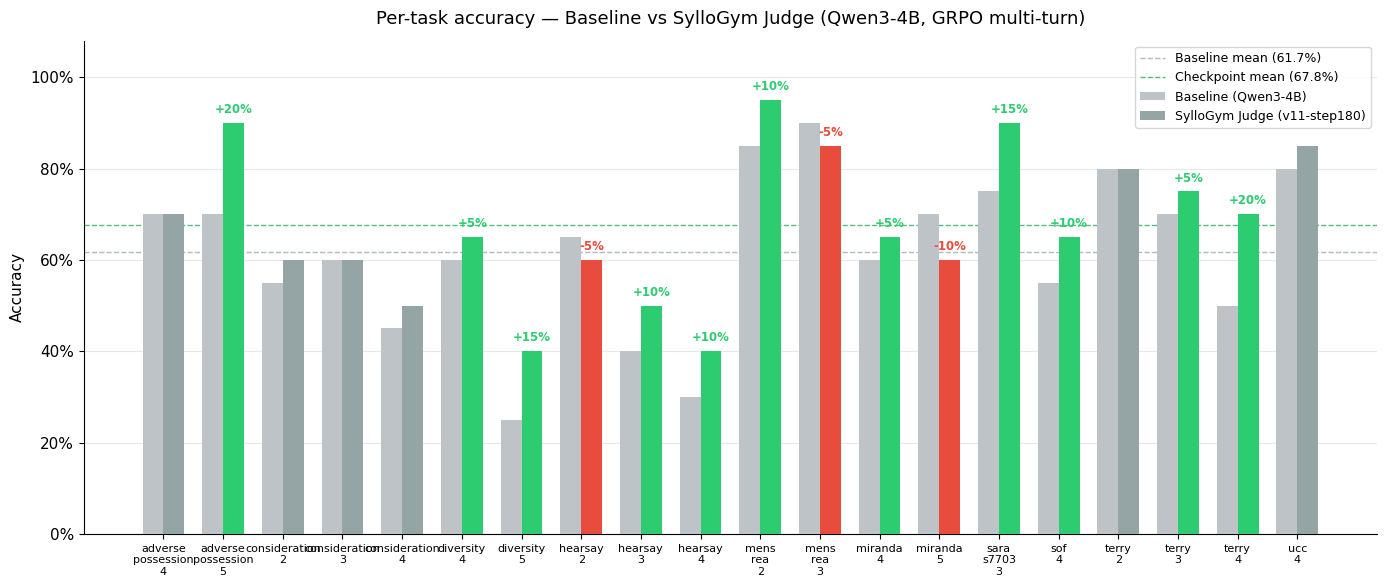

Saved → assets/eval_tasks.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import json
from collections import defaultdict

# ── Load data ────────────────────────────────────────────────────────────────
with open('assets/eval_baseline.json') as f:
    base_ev = json.load(f)
with open('assets/eval_checkpoint.json') as f:
    ckpt_ev = json.load(f)

tasks = sorted(base_ev['task_scores'].keys())
base_acc = [base_ev['task_scores'][t]['accuracy'] for t in tasks]
ckpt_acc = [ckpt_ev['task_scores'][t]['accuracy'] for t in tasks]
deltas   = [c - b for b, c in zip(base_acc, ckpt_acc)]

# ── Color helpers ─────────────────────────────────────────────────────────────
def delta_color(d):
    if d > 0.05:  return '#2ecc71'
    if d < -0.05: return '#e74c3c'
    return '#95a5a6'

STYLE = {
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'font.size':        11,
}
plt.rcParams.update(STYLE)

# ─────────────────────────────────────────────────────────────────────────────
# Fig 1 — Per-task accuracy: baseline vs checkpoint
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(tasks))
w = 0.35
bars_b = ax.bar(x - w/2, base_acc, w, label='Baseline (Qwen3-4B)', color='#bdc3c7', zorder=3)
bars_c = ax.bar(x + w/2, ckpt_acc, w, label='SylloGym Judge (v11-step180)',
                color=[delta_color(d) for d in deltas], zorder=3)

# delta annotations
for xi, d in zip(x, deltas):
    if abs(d) >= 0.05:
        ax.text(xi + w/2, ckpt_acc[tasks.index(tasks[xi])] + 0.015,
                f'{d:+.0%}', ha='center', va='bottom', fontsize=8.5,
                color=delta_color(d), fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([t.replace('_', '\n') for t in tasks], fontsize=8)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.axhline(base_ev['mean_accuracy'], color='#7f8c8d', lw=1, ls='--', alpha=0.6, label=f'Baseline mean ({base_ev["mean_accuracy"]:.1%})')
ax.axhline(ckpt_ev['mean_accuracy'], color='#27ae60', lw=1, ls='--', alpha=0.8, label=f'Checkpoint mean ({ckpt_ev["mean_accuracy"]:.1%})')
ax.legend(loc='upper right', fontsize=9)
ax.set_title('Per-task accuracy — Baseline vs SylloGym Judge (Qwen3-4B, GRPO multi-turn)', fontsize=13, pad=12)
ax.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig('assets/eval_tasks.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → assets/eval_tasks.png')

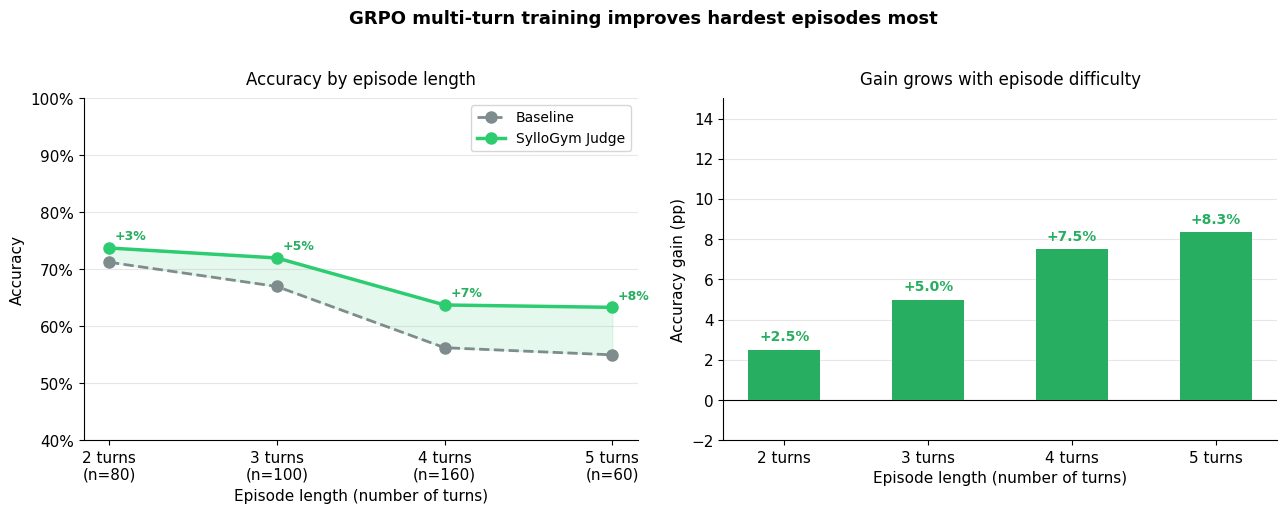

Saved → assets/eval_by_turns.png


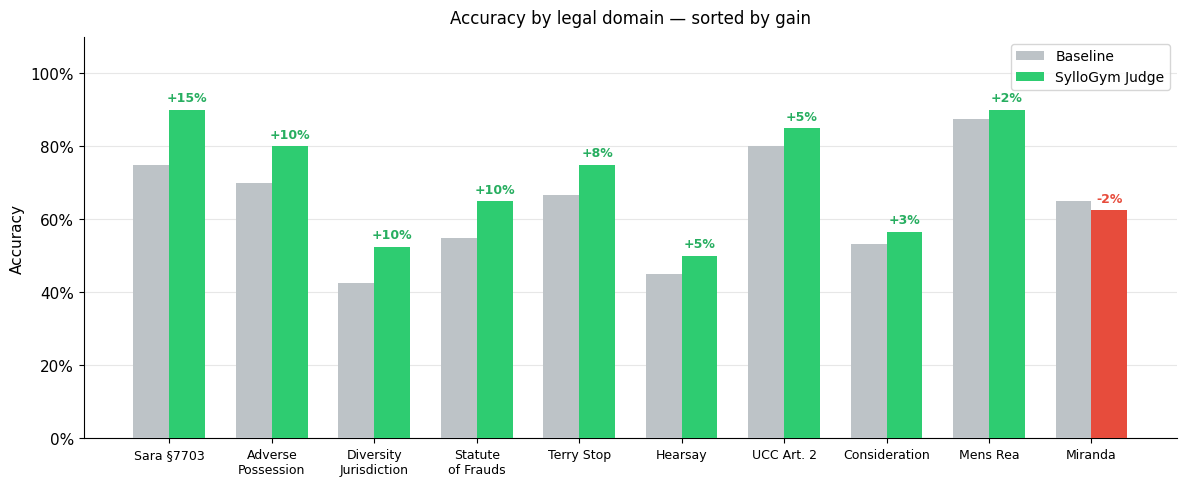

Saved → assets/eval_domains.png


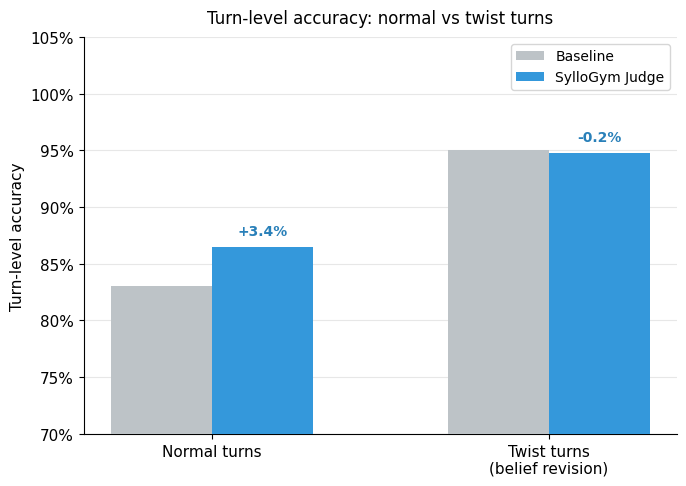

Saved → assets/eval_twist.png


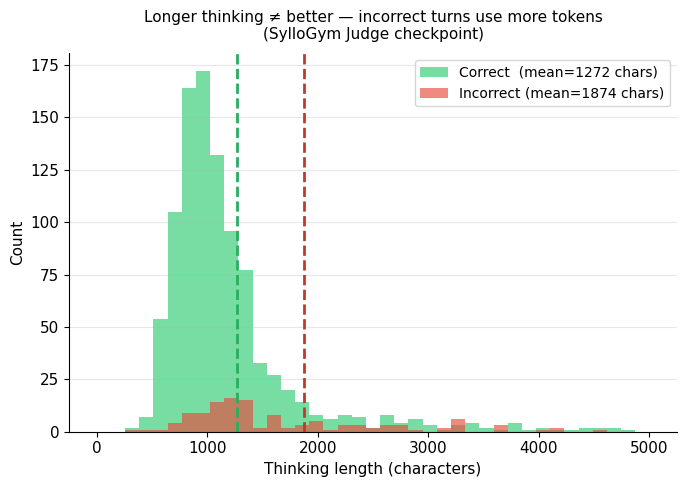

Saved → assets/eval_thinking.png

  SYLLOGYM JUDGE — RESULTS SUMMARY
  Baseline  (Qwen3-4B, no fine-tuning) : 61.7%
  SylloGym Judge (GRPO, 180 steps)     : 67.8%
  Overall gain                         : +6.0%

  Gain by episode length:
    2 turns : 71% → 74%  (+2.5%)
    3 turns : 67% → 72%  (+5.0%)
    4 turns : 56% → 64%  (+7.5%)
    5 turns : 55% → 63%  (+8.3%)
  Twist turn accuracy : 95.0% → 94.8%  (-0.2%)
  Normal turn accuracy: 83.0% → 86.4%  (+3.4%)


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig 2 — Accuracy vs episode length (key insight: gains grow with difficulty)
# ─────────────────────────────────────────────────────────────────────────────
from collections import defaultdict

base_by_turns = defaultdict(list)
ckpt_by_turns = defaultdict(list)
for r in base_ev['results']:
    base_by_turns[r['n_turns']].append(r['correct'])
for r in ckpt_ev['results']:
    ckpt_by_turns[r['n_turns']].append(r['correct'])

turn_counts = sorted(base_by_turns.keys())
base_turn_acc = [np.mean(base_by_turns[n]) for n in turn_counts]
ckpt_turn_acc = [np.mean(ckpt_by_turns[n]) for n in turn_counts]
turn_deltas   = [c - b for b, c in zip(base_turn_acc, ckpt_turn_acc)]
n_episodes    = [len(base_by_turns[n]) for n in turn_counts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: accuracy by turns
ax1.plot(turn_counts, base_turn_acc, 'o--', color='#7f8c8d', lw=2, ms=8, label='Baseline')
ax1.plot(turn_counts, ckpt_turn_acc, 'o-',  color='#2ecc71', lw=2.5, ms=8, label='SylloGym Judge')
for n, b, c in zip(turn_counts, base_turn_acc, ckpt_turn_acc):
    ax1.annotate(f'+{c-b:.0%}', xy=(n, c), xytext=(4, 6), textcoords='offset points',
                 fontsize=9, color='#27ae60', fontweight='bold')
ax1.fill_between(turn_counts, base_turn_acc, ckpt_turn_acc, alpha=0.12, color='#2ecc71')
ax1.set_xlabel('Episode length (number of turns)')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(turn_counts)
ax1.set_xticklabels([f'{n} turns\n(n={e})' for n, e in zip(turn_counts, n_episodes)])
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax1.set_ylim(0.4, 1.0)
ax1.legend(fontsize=10)
ax1.set_title('Accuracy by episode length', fontsize=12, pad=10)
ax1.grid(axis='y', alpha=0.3)

# Right: gain by turns (bar)
colors = ['#27ae60' if d > 0 else '#e74c3c' for d in turn_deltas]
bars = ax2.bar(turn_counts, [d * 100 for d in turn_deltas], color=colors, width=0.5, zorder=3)
ax2.axhline(0, color='black', lw=0.8)
for bar, d in zip(bars, turn_deltas):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'+{d:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#27ae60')
ax2.set_xlabel('Episode length (number of turns)')
ax2.set_ylabel('Accuracy gain (pp)')
ax2.set_xticks(turn_counts)
ax2.set_xticklabels([f'{n} turns' for n in turn_counts])
ax2.set_title('Gain grows with episode difficulty', fontsize=12, pad=10)
ax2.grid(axis='y', alpha=0.3, zorder=0)
ax2.set_ylim(-2, 15)

plt.suptitle('GRPO multi-turn training improves hardest episodes most', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/eval_by_turns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → assets/eval_by_turns.png')


# ─────────────────────────────────────────────────────────────────────────────
# Fig 3 — Domain heatmap
# ─────────────────────────────────────────────────────────────────────────────
DOMAINS = {
    'Adverse\nPossession':  ['adverse_possession_4', 'adverse_possession_5'],
    'Diversity\nJurisdiction': ['diversity_4', 'diversity_5'],
    'Hearsay':              ['hearsay_2', 'hearsay_3', 'hearsay_4'],
    'Miranda':              ['miranda_4', 'miranda_5'],
    'Consideration':        ['consideration_2', 'consideration_3', 'consideration_4'],
    'Mens Rea':             ['mens_rea_2', 'mens_rea_3'],
    'Terry Stop':           ['terry_2', 'terry_3', 'terry_4'],
    'Statute\nof Frauds':   ['sof_4'],
    'Sara §7703':           ['sara_s7703_3'],
    'UCC Art. 2':           ['ucc_4'],
}

domain_names = list(DOMAINS.keys())
domain_base  = [np.mean([base_ev['task_scores'][t]['accuracy'] for t in tasks]) for tasks in DOMAINS.values()]
domain_ckpt  = [np.mean([ckpt_ev['task_scores'][t]['accuracy'] for t in tasks]) for tasks in DOMAINS.values()]
domain_delta = [c - b for b, c in zip(domain_base, domain_ckpt)]

# Sort by delta descending
order = np.argsort(domain_delta)[::-1]
domain_names  = [domain_names[i] for i in order]
domain_base   = [domain_base[i]  for i in order]
domain_ckpt   = [domain_ckpt[i]  for i in order]
domain_delta  = [domain_delta[i] for i in order]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(domain_names))
w = 0.35
ax.bar(x - w/2, domain_base, w, color='#bdc3c7', label='Baseline', zorder=3)
ax.bar(x + w/2, domain_ckpt, w,
       color=['#2ecc71' if d > 0.02 else ('#e74c3c' if d < -0.02 else '#95a5a6') for d in domain_delta],
       label='SylloGym Judge', zorder=3)

for xi, d, c in zip(x, domain_delta, domain_ckpt):
    if abs(d) > 0.01:
        ax.text(xi + w/2, c + 0.015, f'{d:+.0%}', ha='center', va='bottom',
                fontsize=9, fontweight='bold',
                color='#27ae60' if d > 0 else '#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(domain_names, fontsize=9)
ax.set_ylabel('Accuracy')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.set_title('Accuracy by legal domain — sorted by gain', fontsize=12, pad=10)
ax.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig('assets/eval_domains.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → assets/eval_domains.png')


# ─────────────────────────────────────────────────────────────────────────────
# Fig 4 — Twist resilience: accuracy on twist turns vs normal turns
# ─────────────────────────────────────────────────────────────────────────────
def turn_stats(ev):
    twist_c, twist_t, normal_c, normal_t = 0, 0, 0, 0
    for r in ev['results']:
        for t in r.get('turns', []):
            if t['is_twist']:
                twist_t += 1
                if t['correct']: twist_c += 1
            else:
                normal_t += 1
                if t['correct']: normal_c += 1
    return twist_c/twist_t, normal_c/normal_t

base_twist, base_normal = turn_stats(base_ev)
ckpt_twist, ckpt_normal = turn_stats(ckpt_ev)

fig, ax = plt.subplots(figsize=(7, 5))
categories = ['Normal turns', 'Twist turns\n(belief revision)']
base_vals = [base_normal, base_twist]
ckpt_vals = [ckpt_normal, ckpt_twist]
x = np.arange(2)
w = 0.3

ax.bar(x - w/2, base_vals, w, color='#bdc3c7', label='Baseline', zorder=3)
ax.bar(x + w/2, ckpt_vals, w, color='#3498db', label='SylloGym Judge', zorder=3)

for xi, b, c in zip(x, base_vals, ckpt_vals):
    d = c - b
    ax.text(xi + w/2, c + 0.008, f'{d:+.1%}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#2980b9')

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('Turn-level accuracy')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_ylim(0.7, 1.05)
ax.legend(fontsize=10)
ax.set_title('Turn-level accuracy: normal vs twist turns', fontsize=12, pad=10)
ax.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig('assets/eval_twist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → assets/eval_twist.png')


# ─────────────────────────────────────────────────────────────────────────────
# Fig 5 — Thinking length: correct vs incorrect (checkpoint only)
# ─────────────────────────────────────────────────────────────────────────────
think_correct = [len(t['thinking']) for r in ckpt_ev['results']
                 for t in r['turns'] if t.get('thinking') and t['correct']]
think_wrong   = [len(t['thinking']) for r in ckpt_ev['results']
                 for t in r['turns'] if t.get('thinking') and not t['correct']]

fig, ax = plt.subplots(figsize=(7, 5))
bins = np.linspace(0, 5000, 40)
ax.hist(think_correct, bins=bins, alpha=0.65, color='#2ecc71', label=f'Correct  (mean={np.mean(think_correct):.0f} chars)')
ax.hist(think_wrong,   bins=bins, alpha=0.65, color='#e74c3c', label=f'Incorrect (mean={np.mean(think_wrong):.0f} chars)')
ax.axvline(np.mean(think_correct), color='#27ae60', lw=2, ls='--')
ax.axvline(np.mean(think_wrong),   color='#c0392b', lw=2, ls='--')
ax.set_xlabel('Thinking length (characters)')
ax.set_ylabel('Count')
ax.legend(fontsize=10)
ax.set_title('Longer thinking ≠ better — incorrect turns use more tokens\n(SylloGym Judge checkpoint)', fontsize=11, pad=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('assets/eval_thinking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → assets/eval_thinking.png')


# ─────────────────────────────────────────────────────────────────────────────
# Summary printout
# ─────────────────────────────────────────────────────────────────────────────
print()
print('='*55)
print('  SYLLOGYM JUDGE — RESULTS SUMMARY')
print('='*55)
print(f'  Baseline  (Qwen3-4B, no fine-tuning) : {base_ev["mean_accuracy"]:.1%}')
print(f'  SylloGym Judge (GRPO, 180 steps)     : {ckpt_ev["mean_accuracy"]:.1%}')
print(f'  Overall gain                         : +{ckpt_ev["mean_accuracy"]-base_ev["mean_accuracy"]:.1%}')
print()
print('  Gain by episode length:')
for n, b, c in zip(turn_counts, base_turn_acc, ckpt_turn_acc):
    print(f'    {n} turns : {b:.0%} → {c:.0%}  ({c-b:+.1%})')
print(f'  Twist turn accuracy : {base_twist:.1%} → {ckpt_twist:.1%}  ({ckpt_twist-base_twist:+.1%})')
print(f'  Normal turn accuracy: {base_normal:.1%} → {ckpt_normal:.1%}  ({ckpt_normal-base_normal:+.1%})')
print('='*55)

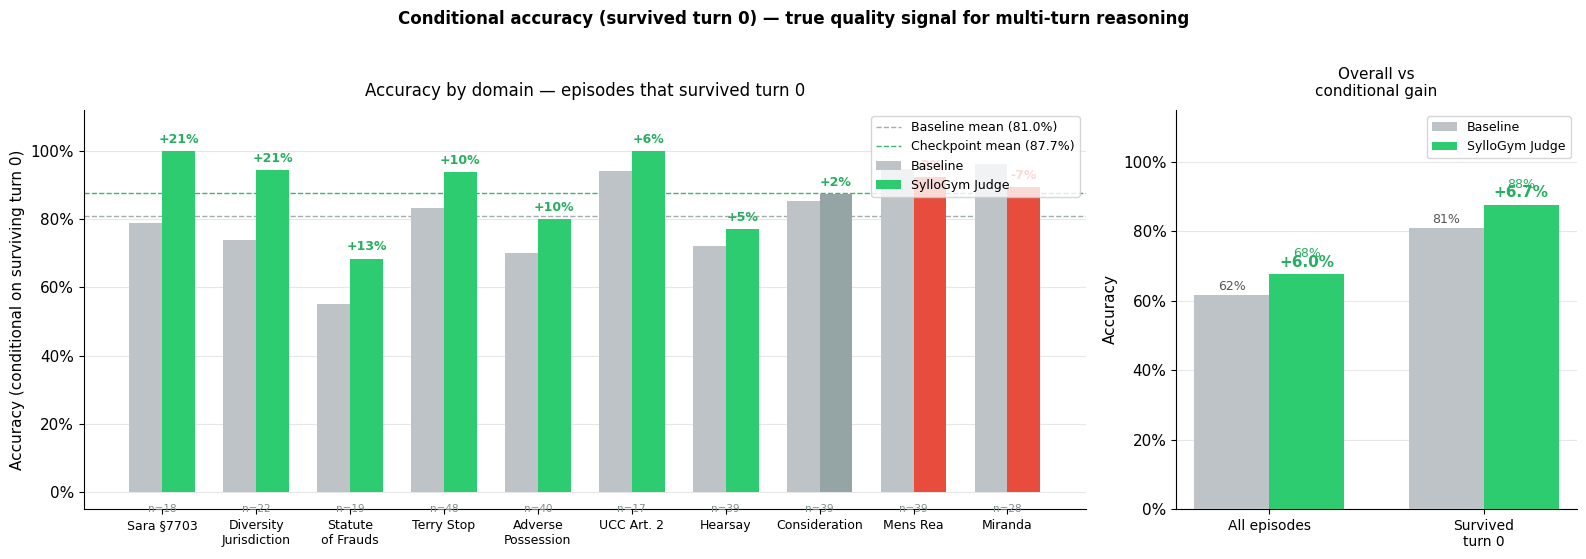

Unconditional  : baseline 61.7% → checkpoint 67.8%  (+6.0%)
Survived turn 0: baseline 81.0% → checkpoint 87.7%  (+6.7%)
Saved → assets/eval_survived_t0.png


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig 6 — Conditional accuracy: episodes that survived turn 0
# Key insight: filtering to episodes where model got turn 0 right shows
# quality gain on the "in-game" subset (model had a chance to improve)
# ─────────────────────────────────────────────────────────────────────────────

DOMAINS = {
    'Adverse\nPossession':     ['adverse_possession_4', 'adverse_possession_5'],
    'Diversity\nJurisdiction': ['diversity_4', 'diversity_5'],
    'Hearsay':                  ['hearsay_2', 'hearsay_3', 'hearsay_4'],
    'Miranda':                  ['miranda_4', 'miranda_5'],
    'Consideration':            ['consideration_2', 'consideration_3', 'consideration_4'],
    'Mens Rea':                 ['mens_rea_2', 'mens_rea_3'],
    'Terry Stop':               ['terry_2', 'terry_3', 'terry_4'],
    'Statute\nof Frauds':      ['sof_4'],
    'Sara §7703':               ['sara_s7703_3'],
    'UCC Art. 2':               ['ucc_4'],
}

def survived_turn0_accuracy(ev):
    """
    For each episode, only count it if turn 0 was answered correctly.
    Return dict: task_name → accuracy on that subset.
    """
    task_survived = defaultdict(list)  # task → [correct_episode, ...]
    for r in ev['results']:
        turns = r.get('turns', [])
        if not turns:
            continue
        if turns[0]['correct']:   # survived turn 0
            task_survived[r['task_name']].append(r['correct'])
    return {t: (np.mean(v), len(v)) for t, v in task_survived.items()}

base_s0 = survived_turn0_accuracy(base_ev)
ckpt_s0 = survived_turn0_accuracy(ckpt_ev)

# Aggregate by domain (only domains with data in both)
domain_names_s0, domain_base_s0, domain_ckpt_s0, domain_n_s0 = [], [], [], []
for dname, task_list in DOMAINS.items():
    b_vals, c_vals, ns = [], [], []
    for t in task_list:
        if t in base_s0 and t in ckpt_s0:
            b_vals.append(base_s0[t][0])
            c_vals.append(ckpt_s0[t][0])
            ns.append(ckpt_s0[t][1])
    if b_vals:
        domain_names_s0.append(dname)
        domain_base_s0.append(np.mean(b_vals))
        domain_ckpt_s0.append(np.mean(c_vals))
        domain_n_s0.append(sum(ns))

domain_delta_s0 = [c - b for b, c in zip(domain_base_s0, domain_ckpt_s0)]

# Sort by delta descending
order = np.argsort(domain_delta_s0)[::-1]
domain_names_s0  = [domain_names_s0[i]  for i in order]
domain_base_s0   = [domain_base_s0[i]   for i in order]
domain_ckpt_s0   = [domain_ckpt_s0[i]   for i in order]
domain_delta_s0  = [domain_delta_s0[i]  for i in order]
domain_n_s0      = [domain_n_s0[i]      for i in order]

# Also compute overall conditional accuracy
all_base_s0  = [v for acc, _ in base_s0.values() for v in [acc]] # placeholder
base_s0_mean = np.mean([v[0] for v in base_s0.values() if v[1] > 0])
ckpt_s0_mean = np.mean([v[0] for v in ckpt_s0.values() if v[1] > 0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={'width_ratios': [2.5, 1]})

# Left: domain bar chart
x = np.arange(len(domain_names_s0))
w = 0.35
ax1.bar(x - w/2, domain_base_s0, w, color='#bdc3c7', label='Baseline', zorder=3)
ax1.bar(x + w/2, domain_ckpt_s0, w,
        color=['#2ecc71' if d > 0.02 else ('#e74c3c' if d < -0.02 else '#95a5a6') for d in domain_delta_s0],
        label='SylloGym Judge', zorder=3)

for xi, d, c, n in zip(x, domain_delta_s0, domain_ckpt_s0, domain_n_s0):
    if abs(d) > 0.005:
        ax1.text(xi + w/2, c + 0.015, f'{d:+.0%}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold',
                 color='#27ae60' if d > 0 else '#e74c3c')
    ax1.text(xi, -0.06, f'n={n}', ha='center', fontsize=7.5, color='#7f8c8d')

ax1.set_xticks(x)
ax1.set_xticklabels(domain_names_s0, fontsize=9)
ax1.set_ylabel('Accuracy (conditional on surviving turn 0)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax1.set_ylim(-0.05, 1.12)
ax1.axhline(base_s0_mean, color='#7f8c8d', lw=1, ls='--', alpha=0.7, label=f'Baseline mean ({base_s0_mean:.1%})')
ax1.axhline(ckpt_s0_mean, color='#27ae60', lw=1, ls='--', alpha=0.9, label=f'Checkpoint mean ({ckpt_s0_mean:.1%})')
ax1.legend(fontsize=9, loc='upper right')
ax1.set_title('Accuracy by domain — episodes that survived turn 0', fontsize=12, pad=10)
ax1.grid(axis='y', alpha=0.3, zorder=0)

# Right: unconditional vs conditional summary
categories  = ['All episodes', 'Survived\nturn 0']
base_both   = [base_ev['mean_accuracy'], base_s0_mean]
ckpt_both   = [ckpt_ev['mean_accuracy'], ckpt_s0_mean]
x2 = np.arange(2)
ax2.bar(x2 - w/2, base_both, w, color='#bdc3c7', label='Baseline', zorder=3)
ax2.bar(x2 + w/2, ckpt_both, w, color='#2ecc71', label='SylloGym Judge', zorder=3)

for xi, b, c in zip(x2, base_both, ckpt_both):
    ax2.text(xi + w/2, c + 0.012, f'{c-b:+.1%}', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='#27ae60' if c >= b else '#e74c3c')
    ax2.text(xi - w/2, b + 0.005, f'{b:.0%}', ha='center', va='bottom', fontsize=9, color='#555')
    ax2.text(xi + w/2, ckpt_both[xi] + 0.04 if xi == 0 else c + 0.04, f'{c:.0%}',
             ha='center', va='bottom', fontsize=9, color='#27ae60')

ax2.set_xticks(x2)
ax2.set_xticklabels(categories, fontsize=10)
ax2.set_ylabel('Accuracy')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax2.set_ylim(0, 1.15)
ax2.legend(fontsize=9)
ax2.set_title('Overall vs\nconditional gain', fontsize=11, pad=10)
ax2.grid(axis='y', alpha=0.3, zorder=0)

plt.suptitle('Conditional accuracy (survived turn 0) — true quality signal for multi-turn reasoning',
             fontsize=12, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/eval_survived_t0.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Unconditional  : baseline {base_ev["mean_accuracy"]:.1%} → checkpoint {ckpt_ev["mean_accuracy"]:.1%}  ({ckpt_ev["mean_accuracy"]-base_ev["mean_accuracy"]:+.1%})')
print(f'Survived turn 0: baseline {base_s0_mean:.1%} → checkpoint {ckpt_s0_mean:.1%}  ({ckpt_s0_mean-base_s0_mean:+.1%})')
print('Saved → assets/eval_survived_t0.png')

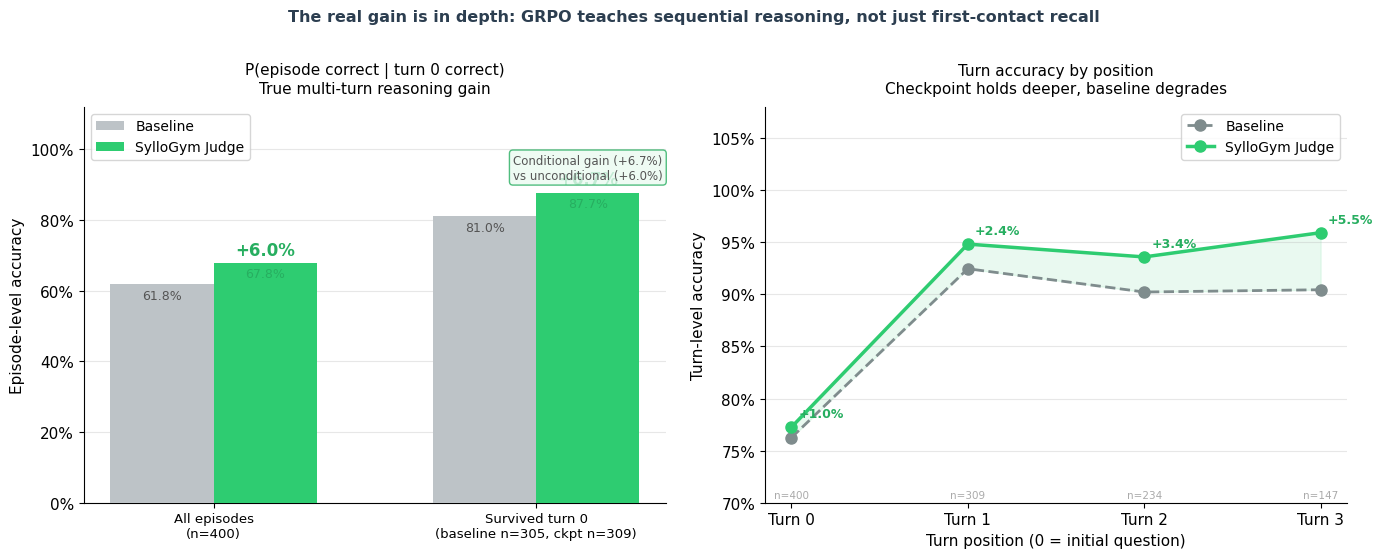

All episodes     : baseline 61.8% → checkpoint 67.8%  (+6.0%)
Survived turn 0  : baseline 81.0% → checkpoint 87.7%  (+6.7%)

Turn-level accuracy by position (capped at turn 3 — turn 4 n too small):
  Turn 0: 76.2% → 77.2%  (+1.0%)
  Turn 1: 92.5% → 94.8%  (+2.4%)
  Turn 2: 90.2% → 93.6%  (+3.4%)
  Turn 3: 90.4% → 95.9%  (+5.5%)
  Turn 4: 100.0% → 97.4%  (-2.6%)  ⚠ n=33/39, baseline ceiling 100%
Saved → assets/eval_depth_signal.png


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Fig 7 — Two key conditional insights
#   Left:  P(episode correct | turn 0 correct) — the "depth reasoning" signal
#   Right: Turn-level accuracy by position — baseline degrades, ckpt holds
# ─────────────────────────────────────────────────────────────────────────────
from collections import defaultdict

# ── 1. P(complete | T0 correct) ──────────────────────────────────────────────
def p_complete_given_t0(ev):
    t0_correct_episodes = [r for r in ev['results'] if r['turns'] and r['turns'][0]['correct']]
    all_episodes        = ev['results']
    p_all    = sum(r['correct'] for r in all_episodes) / len(all_episodes)
    p_cond   = sum(r['correct'] for r in t0_correct_episodes) / len(t0_correct_episodes)
    n_cond   = len(t0_correct_episodes)
    return p_all, p_cond, n_cond

base_p_all, base_p_cond, base_n = p_complete_given_t0(base_ev)
ckpt_p_all, ckpt_p_cond, ckpt_n = p_complete_given_t0(ckpt_ev)

# ── 2. Turn-level accuracy by position ───────────────────────────────────────
def turn_acc_by_position(ev):
    pos = defaultdict(list)
    for r in ev['results']:
        for t in r['turns']:
            pos[t['turn_idx']].append(t['correct'])
    positions = sorted(pos.keys())
    return positions, [np.mean(pos[p]) for p in positions], [len(pos[p]) for p in positions]

base_pos_all, base_pos_acc_all, base_pos_n_all = turn_acc_by_position(base_ev)
ckpt_pos_all, ckpt_pos_acc_all, ckpt_pos_n_all = turn_acc_by_position(ckpt_ev)

# Cap at turn 3 — turn 4 has n=33/39, baseline at 100% ceiling → not interpretable
MAX_TURN = 3
base_pos = [p for p in base_pos_all if p <= MAX_TURN]
base_pos_acc = [a for p, a in zip(base_pos_all, base_pos_acc_all) if p <= MAX_TURN]
base_pos_n   = [n for p, n in zip(base_pos_all, base_pos_n_all)   if p <= MAX_TURN]
ckpt_pos = [p for p in ckpt_pos_all if p <= MAX_TURN]
ckpt_pos_acc = [a for p, a in zip(ckpt_pos_all, ckpt_pos_acc_all) if p <= MAX_TURN]
ckpt_pos_n   = [n for p, n in zip(ckpt_pos_all, ckpt_pos_n_all)   if p <= MAX_TURN]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: P(complete | T0 correct)
categories = ['All episodes', 'Survived\nturn 0']
base_bars  = [base_p_all, base_p_cond]
ckpt_bars  = [ckpt_p_all, ckpt_p_cond]
x = np.arange(2)
w = 0.32

ax1.bar(x - w/2, base_bars, w, color='#bdc3c7', label='Baseline', zorder=3)
ax1.bar(x + w/2, ckpt_bars, w, color='#2ecc71', label='SylloGym Judge', zorder=3)

for xi, b, c in zip(x, base_bars, ckpt_bars):
    d = c - b
    col = '#27ae60' if d >= 0 else '#e74c3c'
    ax1.text(xi + w/2, c + 0.012, f'{d:+.1%}', ha='center', va='bottom',
             fontsize=12, fontweight='bold', color=col)
    ax1.text(xi - w/2, b - 0.04, f'{b:.1%}', ha='center', fontsize=9, color='#555')
    ax1.text(xi + w/2, c - 0.04, f'{c:.1%}', ha='center', fontsize=9, color='#27ae60')

# n= annotations under x-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels([
    f'All episodes\n(n={len(base_ev["results"])})',
    f'Survived turn 0\n(baseline n={base_n}, ckpt n={ckpt_n})'
], fontsize=9.5)
ax1.set_ylabel('Episode-level accuracy')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax1.set_ylim(0, 1.12)
ax1.legend(fontsize=10)
ax1.set_title('P(episode correct | turn 0 correct)\nTrue multi-turn reasoning gain', fontsize=11, pad=10)
ax1.grid(axis='y', alpha=0.3, zorder=0)

# Highlight gain difference
delta_all  = ckpt_p_all  - base_p_all
delta_cond = ckpt_p_cond - base_p_cond
ax1.annotate(
    f'Conditional gain ({delta_cond:+.1%})\nvs unconditional ({delta_all:+.1%})',
    xy=(1 + w/2, ckpt_p_cond + 0.04), fontsize=8.5, color='#555',
    ha='center',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#eafaf1', edgecolor='#27ae60', alpha=0.8)
)

# Right: accuracy by turn position
ax2.plot(base_pos, base_pos_acc, 'o--', color='#7f8c8d', lw=2, ms=8, label='Baseline', zorder=3)
ax2.plot(ckpt_pos, ckpt_pos_acc, 'o-',  color='#2ecc71', lw=2.5, ms=8, label='SylloGym Judge', zorder=3)

for p, b, c, n in zip(base_pos, base_pos_acc, ckpt_pos_acc, ckpt_pos_n):
    d = c - b
    col = '#27ae60' if d >= 0 else '#e74c3c'
    ax2.annotate(f'{d:+.1%}', xy=(p, c), xytext=(5, 7), textcoords='offset points',
                 fontsize=9, color=col, fontweight='bold')
    ax2.text(p, 0.705, f'n={n}', ha='center', fontsize=7.5, color='#aaa')

ax2.fill_between(base_pos, base_pos_acc, ckpt_pos_acc, alpha=0.1, color='#2ecc71')
ax2.set_xlabel('Turn position (0 = initial question)')
ax2.set_ylabel('Turn-level accuracy')
ax2.set_xticks(base_pos)
ax2.set_xticklabels([f'Turn {p}' for p in base_pos])
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax2.set_ylim(0.7, 1.08)
ax2.legend(fontsize=10)
ax2.set_title('Turn accuracy by position\nCheckpoint holds deeper, baseline degrades', fontsize=11, pad=10)
ax2.grid(axis='y', alpha=0.3, zorder=0)

plt.suptitle('The real gain is in depth: GRPO teaches sequential reasoning, not just first-contact recall',
             fontsize=11.5, y=1.01, fontweight='bold', color='#2c3e50')
plt.tight_layout()
plt.savefig('assets/eval_depth_signal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'All episodes     : baseline {base_p_all:.1%} → checkpoint {ckpt_p_all:.1%}  ({ckpt_p_all-base_p_all:+.1%})')
print(f'Survived turn 0  : baseline {base_p_cond:.1%} → checkpoint {ckpt_p_cond:.1%}  ({ckpt_p_cond-base_p_cond:+.1%})')
print()
print('Turn-level accuracy by position (capped at turn 3 — turn 4 n too small):')
for p, b, c in zip(base_pos_all, base_pos_acc_all, ckpt_pos_acc_all):
    note = '  ⚠ n=33/39, baseline ceiling 100%' if p == 4 else ''
    print(f'  Turn {p}: {b:.1%} → {c:.1%}  ({c-b:+.1%}){note}')
print('Saved → assets/eval_depth_signal.png')


## 9. Debug — Single Episode

In [ ]:
TASK = 'diversity_3'
SEED = 0
MODEL_LABEL = 'baseline'  # 'baseline' or 'checkpoint'

model_dbg    = base_model    if MODEL_LABEL == 'baseline' else ckpt_model
tokenizer_dbg = base_tokenizer if MODEL_LABEL == 'baseline' else ckpt_tokenizer

print(f'=== Debug episode: {TASK}  seed={SEED}  model={MODEL_LABEL} ===')
r = run_episode(model_dbg, tokenizer_dbg, task_name=TASK, seed=SEED)

print(f'\nReward  : {r["reward"]:.3f}')
print(f'Correct : {r["correct"]}')
print(f'Turns   : {r["n_turns"]}')
print()
for t in r['turns']:
    twist = ' [TWIST]' if t['is_twist'] else ''
    thinking = t.get('thinking', '')[:300].replace('\n', ' ')
    print(f'Turn {t["turn_idx"]+1}{twist}')
    if t.get('new_info'):
        print(f'  new_info : {t["new_info"]}')
    if thinking:
        print(f'  <think>  : {thinking}...')
    print(f'  answer   : {t["answer"]!r}  →  correct={t.get("correct", "?")}')
    if t.get('correct_answer'):
        print(f'  expected : {t["correct_answer"]!r}')
    print()
print('Full trace → eval.log')